In [54]:
## Let's go through the entire pipeline, for a single mesh. Checking each step of the process.
from pathlib import Path
import pandas as pd
import sys
import re

# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import cross_section_helpers as csh

chosen_mesh = ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']
chosen_mesh = ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4']
colours = {
    'realistic': 'blue',
    'simplified_circular': 'orange',
    'simplified_oval': 'green'
}

## Load in the results
path_to_data = "../Meshes/"
confocal_results = "Onion meshes/pressure_pore/"
confocal_meshes = "Onion meshes/pressure_results/"
idealised_results = "Idealised/pressure_pore/"
idealised_meshes = "Idealised/pressure_results/"

## Define the pattern for the file names
mesh_file_pattern = r"Ac_DA_([^_]+_[^_]+)_([0-9]+\.?[0-9]*)\.obj"
results_file_pattern = r"pore_area_Ac_DA_([^_]+_[^_]+)\.txt"

def extract_id_and_pressure(filename, pattern):
    """
    Extract ID and pressure from filename using the defined pattern.
    
    Args:
        filename (str): Filename like "Ac_DA_1_2_0.0.obj"
    
    Returns:
        tuple: (id, pressure) or (None, None) if no match
    """
    match = re.search(pattern, str(filename))
    if match:
        id_part = match.group(1)  # e.g., "1_2"
        if len(match.groups()) > 1:
            pressure = float(match.group(2))  # e.g., 0.0
            return (id_part, pressure)
        else:
            return (id_part, None)
    return (None, None)

## Get all files in the folder
confocal_results_files = [f for f in Path(path_to_data + confocal_results).glob("*.txt")]
confocal_mesh_files = [f for f in Path(path_to_data + confocal_meshes).glob("*.obj")]


## Keep only the chosen mesh values 
chosen_confocal_results_files = [f for f in confocal_results_files if extract_id_and_pressure(f.name, results_file_pattern)[0] in chosen_mesh]
chosen_confocal_mesh_files = [f for f in confocal_mesh_files if extract_id_and_pressure(f.name, mesh_file_pattern)[0] in chosen_mesh]

In [11]:
## Populate the two dataframes
import importlib
import mesh_functions
importlib.reload(mesh_functions)  # Reload to get the latest changes
import pandas as pd
from mesh_functions import process_mesh
from concurrent.futures import ThreadPoolExecutor, as_completed

confocal_results_chosen = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_mesh, file) for file in chosen_confocal_mesh_files]
    for future in as_completed(futures):
        confocal_results_chosen.append(future.result())

df_chosen = pd.DataFrame(confocal_results_chosen)


In [12]:
df_chosen.to_csv("confocal_chosen_results.csv", index=False)

In [13]:
df_chosen.head(5)

,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right
0,2_7,confocal,0.3,1.079475,1.050837,"[[27.292157424181106, 5.6765018818492505, -6.8...","[[47.28064723990161, 1.4666494257476872, -9.17...",1.014138,0.970357,"[[22.09536180477617, -7.4470755037162855, -12....","[[32.31500608941463, 10.84967954622312, -9.310...",13.047880,12.435028,12.087251,11.833452
1,2_3,confocal,0.1,1.128438,1.049967,"[[-1.1852250337171744, 11.814485364055681, 2.2...","[[18.38593288691933, 7.216400299093127, -0.136...",1.064460,1.047129,"[[10.833925126266612, 2.1250707970323983, -1.2...","[[15.938025536674367, 13.113077365849628, -3.9...",12.982325,14.066034,11.504687,13.396638
2,2_3,confocal,1.6,1.013034,0.980038,"[[-3.9705484295304103, 11.712248126383757, -4....","[[20.78721824236718, 5.668533382940508, -7.876...",1.078737,1.027160,"[[7.57504359478249, -1.1149709110957438, 6.392...","[[16.0917487820478, 13.211845427365215, -3.923...",13.253711,14.854784,13.083190,15.157356
3,2_3,confocal,1.3,1.015408,0.975843,"[[6.19775547864002, 8.720201373291331, -7.2688...","[[17.943057971079675, 6.641442846935108, -2.89...",1.076494,1.029994,"[[9.000956067774496, -0.12898578396091673, -5....","[[16.09288584538465, 13.185446413293944, -3.90...",13.077363,14.564979,12.878931,14.925540
4,2_3,confocal,0.6,1.039100,0.969906,"[[-3.750394609305639, 11.710388033597885, -3.7...","[[32.41471924702593, 5.247325532205374, -2.863...",1.083819,1.043081,"[[9.023997539650544, -0.09035460101643193, -5....","[[16.057429527517126, 13.14611559572431, -3.99...",12.781838,13.850782,12.300880,14.280534


In [ ]:
## Add in volume and pore area to the dataframe
import trimesh
import numpy as np
import mesh_functions as mf
import idealised_mesh_functions as imf
importlib.reload(mesh_functions)  # Reload to get the latest changes
import pandas as pd

pressures = np.arange(0,2.1, 0.1)

df_full = mf.get_pore_area_and_volume(df_chosen, chosen_confocal_results_files[0], chosen_confocal_mesh_files, pressures)
## Add in major and minor lengths
for mesh_id in chosen_mesh:
    mesh = trimesh.load(f"../Meshes/Onion_OBJ/Ac_DA_{mesh_id}.obj", force='mesh')
    length_major, length_minor = imf.get_major_minor_stomata(mesh)
    
    # Update all rows for this mesh_id (or just pressure==0.0 if you prefer)
    df_chosen.loc[df_chosen["Mesh ID"] == mesh_id, "Measured major length"] = length_major
    df_chosen.loc[df_chosen["Mesh ID"] == mesh_id, "Measured minor length"] = length_minor

print(df_chosen[["Mesh ID", "Measured major length", "Measured minor length"]].head())
display(df_chosen.head(5))

  Mesh ID  Measured major length  Measured minor length
0     1_2              42.674713              38.841329
1     1_2              42.674713              38.841329
2     1_2              42.674713              38.841329
3     1_2              42.674713              38.841329
4     1_2              42.674713              38.841329


,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume,Measured major length,Measured minor length
0,1_2,confocal,1.5,1.004519,1.071766,"[[-2.2835220873669697, 0.6754736857717474, -1....","[[20.830716261167556, -1.3640256072482098, -1....",1.027216,1.081368,"[[-7.01440154409436, -18.54852416201539, -0.00...","[[5.521921307652205, 12.76157262786778, 9.3355...",14.574151,16.038309,14.508588,14.964382,62.28,14515.114811,42.674713,38.841329
1,1_2,confocal,1.3,1.005229,1.081492,"[[-9.556449393941524, 1.9708555193429207, -7.5...","[[20.815357130334405, -1.41166354973275, -0.82...",1.028984,1.093794,"[[-1.0880025622496978, -8.863339621810992, 4.1...","[[2.334734213382744, 6.517776080695615, 0.0560...",14.421564,15.935932,14.346541,14.735137,61.76,14174.291512,42.674713,38.841329
2,1_2,confocal,0.1,1.214941,1.266045,"[[-13.662724405559624, 2.0697517879248077, -5....","[[7.301126278253114, 0.06435813422822423, -4.4...",1.093258,1.144805,"[[0.7295981482904699, -5.509246261944273, -1.4...","[[2.5548820393487417, 6.525504056002128, 2.689...",14.785460,15.955745,12.169694,12.602829,51.38,11946.035510,42.674713,38.841329
3,1_2,confocal,1.6,0.999384,1.070289,"[[-13.711348848650589, 0.9681302218718985, 5.3...","[[5.209600838029598, 0.005210482577454489, -2....",1.021888,1.079732,"[[-7.073270735279848, -18.612763709142005, -0....","[[5.414404488548416, 12.522897903386074, -4.96...",14.614279,16.120748,14.623288,15.062054,62.40,14686.489640,42.674713,38.841329
4,1_2,confocal,0.7,1.033405,1.108437,"[[-12.774401794149947, -0.051097760213765026, ...","[[19.235835089435128, 0.7368028737948524, 3.52...",0.993414,1.107954,"[[0.9604316749424026, -6.534522768186448, -1.6...","[[2.967084308919959, 7.597026873189469, 5.0533...",14.149535,15.578784,13.692143,14.054735,59.68,13147.732807,42.674713,38.841329


In [18]:
## Add in volume and pore area to the dataframe for ALL meshes
import trimesh
import numpy as np
import mesh_functions as mf
import idealised_mesh_functions as imf
importlib.reload(mf)  # Reload to get the latest changes
import pandas as pd

pressures = np.arange(0, 2.1, 0.1)

# Process each confocal results file with its corresponding mesh files
df_full_list = []
for results_file in chosen_confocal_results_files:
    # Extract the mesh ID from the results file
    mesh_id = extract_id_and_pressure(results_file.name, results_file_pattern)[0]
    
    # Only the rows for this mesh_id
    df_mesh = df_chosen[df_chosen["Mesh ID"] == mesh_id].copy()
    if df_mesh.empty:
        print(f"Warning: No rows in df_chosen for mesh ID {mesh_id}")
        continue

    # Find all mesh files that match this mesh ID
    matching_mesh_files = [
        f for f in chosen_confocal_mesh_files
        if extract_id_and_pressure(f.name, mesh_file_pattern)[0] == mesh_id
    ]
    
    if matching_mesh_files:
        print(f"Processing {len(matching_mesh_files)} mesh files for mesh ID {mesh_id}")
        df_temp = mf.get_pore_area_and_volume(df_mesh, results_file, matching_mesh_files, pressures)
        df_full_list.append(df_temp)
    else:
        print(f"Warning: No mesh files found for mesh ID {mesh_id}")

# Combine all the per-mesh dataframes (no duplicates now)
df_full = pd.concat(df_full_list, ignore_index=True)

# Optional: ensure ordering
df_full = df_full.sort_values(["Mesh ID", "Pressure"]).reset_index(drop=True)

# Add major/minor lengths for ALL meshes
for mesh_id in chosen_mesh:
    try:
        mesh = trimesh.load(f"../Meshes/Onion_OBJ/Ac_DA_{mesh_id}.obj", force='mesh')
        length_major, length_minor = imf.get_major_minor_stomata(mesh)
        df_full.loc[df_full["Mesh ID"] == mesh_id, "Measured major length"] = length_major
        df_full.loc[df_full["Mesh ID"] == mesh_id, "Measured minor length"] = length_minor
        print(f"Processed mesh {mesh_id}: major={length_major:.2f}, minor={length_minor:.2f}")
    except Exception as e:
        print(f"Error processing mesh {mesh_id}: {e}")

print("\nSample of results:")
print(df_full[["Mesh ID", "Pressure", "Pore Area", "Volume", "Measured major length", "Measured minor length"]].head(10))
display(df_full.head(10))

# Save the full results
df_full.to_csv("confocal_full_results.csv", index=False)
print(f"\nSaved {len(df_full)} rows to confocal_full_results.csv")

Processing 21 mesh files for mesh ID 1_3
Processing 21 mesh files for mesh ID 2_1
Processing 21 mesh files for mesh ID 2_7
Processing 21 mesh files for mesh ID 2_6a
Processing 21 mesh files for mesh ID 1_8
Processing 21 mesh files for mesh ID 3_4
Processing 21 mesh files for mesh ID 2_3
Processing 21 mesh files for mesh ID 1_4
Processing 21 mesh files for mesh ID 3_7
Processing 21 mesh files for mesh ID 1_2
Processing 21 mesh files for mesh ID 1_6
Processing 21 mesh files for mesh ID 3_6
Processing 21 mesh files for mesh ID 3_2
Processing 21 mesh files for mesh ID 1_5
Processed mesh 1_2: major=42.67, minor=38.84
Processed mesh 1_3: major=41.32, minor=38.25
Processed mesh 1_4: major=40.36, minor=35.07
Processed mesh 1_5: major=45.44, minor=41.26
Processed mesh 1_6: major=44.99, minor=37.01
Processed mesh 1_8: major=41.47, minor=37.55
Processed mesh 2_1: major=37.52, minor=36.25
Processed mesh 2_3: major=39.98, minor=37.51
Processed mesh 2_6a: major=39.37, minor=37.07
Processed mesh 2_7:

,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume,Measured major length,Measured minor length
0,1_2,confocal,0.0,1.547294,1.614322,"[[-7.1807921779133395, -0.9936780099304432, 3....","[[7.2320269055121065, -0.00933082221608067, 4....",1.035408,1.187306,"[[0.9010459555129395, -7.016356433165035, -2.0...","[[6.709810837908202, 14.645994952653645, 7.743...",16.176377,17.431054,10.454621,10.797753,40.83,11304.069030,42.674713,38.841329
1,1_2,confocal,0.1,1.214941,1.266045,"[[-13.662724405559624, 2.0697517879248077, -5....","[[7.301126278253114, 0.06435813422822423, -4.4...",1.093258,1.144805,"[[0.7295981482904699, -5.509246261944273, -1.4...","[[2.5548820393487417, 6.525504056002128, 2.689...",14.785460,15.955745,12.169694,12.602829,51.38,11946.035510,42.674713,38.841329
2,1_2,confocal,0.2,1.142161,1.171293,"[[-15.592959330608586, -0.3262197220258022, -4...","[[8.432637454587182, 0.08465305825779662, 5.63...",1.013751,1.124223,"[[0.9473880209416163, -6.417954350675626, -1.7...","[[8.289275073049376, 18.249767269550976, -3.68...",14.477197,15.413551,12.675273,13.159431,53.99,12193.658710,42.674713,38.841329
3,1_2,confocal,0.3,1.120650,1.139353,"[[-2.1222391315116163, -0.06864579540096732, -...","[[12.247094192631739, 1.4824844689091576, -6.4...",1.007847,1.129600,"[[0.9382034227443323, -6.422509827403589, -1.7...","[[9.236492089494815, 20.05680974073972, 1.4230...",14.419697,15.326700,12.867264,13.452110,55.94,12406.117507,42.674713,38.841329
4,1_2,confocal,0.4,1.086279,1.133716,"[[-13.567997485697118, -1.0524038292581863, 4....","[[10.357759580897508, 0.13069217619024937, 6.6...",1.006761,1.124783,"[[0.9351328012335193, -6.4352153441716275, -1....","[[3.3356784538917745, 8.29222590386929, 6.0370...",14.263814,15.412916,13.130892,13.595043,57.21,12603.121073,42.674713,38.841329
5,1_2,confocal,0.5,1.063660,1.126495,"[[-7.116786310165259, -0.876510605789347, 5.16...","[[14.855680215265956, 1.541865316593472, -6.42...",0.999876,1.115014,"[[0.947795334444741, -6.476709768732597, -1.69...","[[6.735403958703852, 15.037056936987506, 8.521...",14.194867,15.500839,13.345303,13.760234,58.28,12790.615995,42.674713,38.841329
6,1_2,confocal,0.6,1.048285,1.116161,"[[-5.058546354518787, 0.27268048576417486, -5....","[[7.421469155292158, 0.08457640221913693, 5.37...",0.990765,1.114749,"[[0.9434766048208365, -6.4874237799284185, -1....","[[2.4295036015531206, 6.6509530224338445, 2.54...",14.172110,15.539086,13.519332,13.921906,58.97,12971.244337,42.674713,38.841329
7,1_2,confocal,0.7,1.033405,1.108437,"[[-12.774401794149947, -0.051097760213765026, ...","[[19.235835089435128, 0.7368028737948524, 3.52...",0.993414,1.107954,"[[0.9604316749424026, -6.534522768186448, -1.6...","[[2.967084308919959, 7.597026873189469, 5.0533...",14.149535,15.578784,13.692143,14.054735,59.68,13147.732807,42.674713,38.841329
8,1_2,confocal,0.8,1.021453,1.098353,"[[-12.605431243128574, -1.285116750853389, 5.1...","[[5.368319044098424, 0.6732703500458465, -2.28...",0.990620,1.105586,"[[-0.1535644646313829, -9.375974766386967, -5....","[[3.955240328608576, 9.490008035310137, 7.5485...",14.140634,15.601643,13.843648,14.204576,60.13,13321.581212,42.674713,38.841329
9,1_2,confocal,0.9,1.014054,1.087506,"[[-6.064643605455058, 0.2616201764726741, -6.4...","[[18.933783943980895, 1.5638740811336522, -4.4...",0.985070,1.101518,"[[0.9480028436931204, -6.549277406683836, -1.6...","[[5.839379141894546, 13.213932592084479, 9.074...",14.166474,15.612850,13.970134,14.356568,60.64,13493.686435,42.674713,38.841329



Saved 294 rows to confocal_full_results.csv


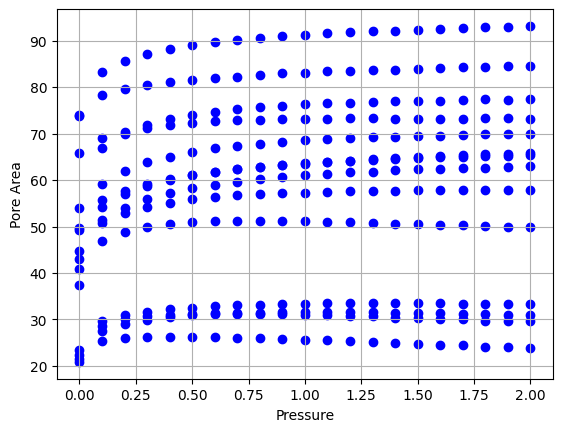

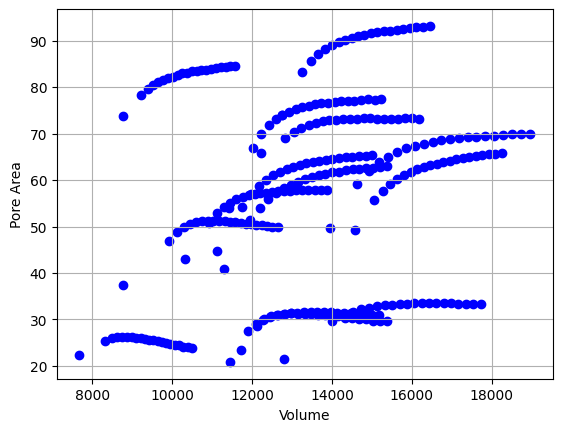

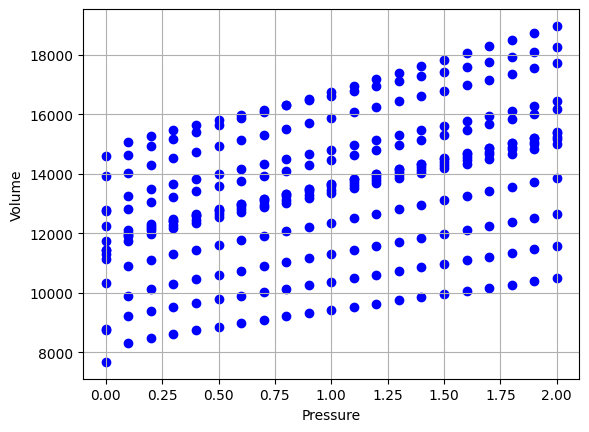

In [19]:
## Plot pressure vs pore area
import matplotlib.pyplot as plt

plt.scatter(df_full['Pressure'], df_full['Pore Area'], marker='o', color='blue')
plt.xlabel('Pressure')
plt.ylabel('Pore Area')
plt.grid(True)
plt.show()

## Plot volume vs pore area
plt.scatter(df_full['Volume'], df_full['Pore Area'], marker='o', color='blue')
plt.xlabel('Volume')
plt.ylabel('Pore Area')
plt.grid(True)
plt.show()

## Plot pressure vs volume
plt.scatter(df_full['Pressure'], df_full['Volume'], marker='o', color='blue')
plt.xlabel('Pressure')
plt.ylabel('Volume')
plt.grid(True)
plt.show()



In [23]:
## What if we were to normalise the volume?

import numpy as np

group_cols = ['Mesh ID', 'Cross-section type'] if 'Cross-section type' in df_full.columns else ['Mesh ID']

# Find baseline (p ≈ 0.0) volume per group
p0_mask = np.isclose(df_full['Pressure'].astype(float), 0.0, atol=1e-2)
baseline = (df_full.loc[p0_mask, group_cols + ['Volume']]
            .rename(columns={'Volume': 'Volume_baseline'}))

# Merge baseline back and compute normalised volume
df_full = df_full.merge(baseline, on=group_cols, how='left')
df_full['Volume norm'] = df_full['Volume'] / df_full['Volume_baseline']

# Optional cleanup
df_full.drop(columns=['Volume_baseline'], inplace=True)

# Quick check (first mesh shown)
display(df_full.loc[df_full['Mesh ID'].eq(df_full['Mesh ID'].iloc[0]),
                    group_cols + ['Pressure', 'Volume', 'Volume norm']].head(10))

,Mesh ID,Cross-section type,Pressure,Volume,Volume norm
0,1_2,confocal,0.0,11304.069030,1.000000
1,1_2,confocal,0.1,11946.035510,1.056791
2,1_2,confocal,0.2,12193.658710,1.078696
3,1_2,confocal,0.3,12406.117507,1.097491
4,1_2,confocal,0.4,12603.121073,1.114919
5,1_2,confocal,0.5,12790.615995,1.131505
6,1_2,confocal,0.6,12971.244337,1.147485
7,1_2,confocal,0.7,13147.732807,1.163097
8,1_2,confocal,0.8,13321.581212,1.178477
9,1_2,confocal,0.9,13493.686435,1.193702


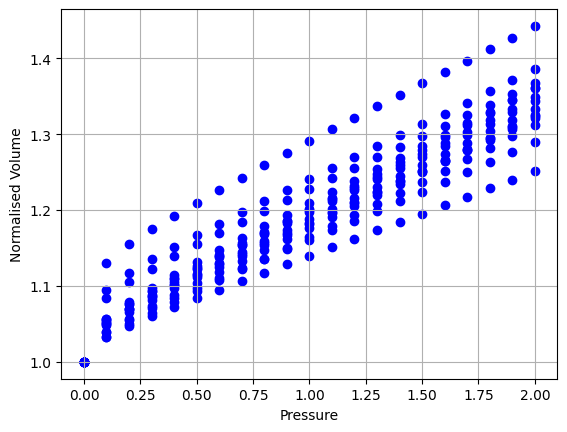

In [25]:
plt.scatter(df_full['Pressure'], df_full['Volume norm'], marker='o', color='blue')
plt.xlabel('Pressure')
plt.ylabel('Normalised Volume')
plt.grid(True)
plt.show()

In [21]:
## Create the idealised meshes

imf.run_idealised_mesh_creation(chosen_mesh, df_full, major_segments=100, minor_segments=50, ar="oval")
imf.run_idealised_mesh_creation(chosen_mesh, df_full, major_segments=100, minor_segments=50, ar="circular")

Processing mesh: 1_2
Target pore area: 40.83
Target midsection aspect ratio: 1.5472944059232716
Target length: 42.67471343341737
Target width: 38.841328678137174
Initial minor radii: a=8.0882, b=5.2273
Initial major radii: a=11.3325, b=13.2492

Attempt 1:
Central pore area: 51.60
Difference from target pore area: -10.77
Adjusting minor radii by -0.2134 to a=8.3016, b=5.4407
New major radii: a=11.1191, b=13.0357

Attempt 2:
Central pore area: 40.84
Difference from target pore area: -0.01
Pore area within acceptable range. Stopping iterations.
Final mesh saved as: idealised_final_1_2_oval.ply
Completed processing mesh 1_2
Processing mesh: 1_3
Target pore area: 44.63
Target midsection aspect ratio: 1.4524772174794578
Target length: 41.31916278837673
Target width: 38.24586474713641
Initial minor radii: a=7.9248, b=5.4561
Initial major radii: a=11.1981, b=12.7348

Attempt 1:
Central pore area: 48.81
Difference from target pore area: -4.18
Adjusting minor radii by -0.0742 to a=7.9990, b=5.53

In [ ]:
importlib.reload(mesh_functions)  # Reload to get the latest changes
from mesh_functions import extract_id_type_pressure

## Load in the data for the idealised meshes
idealised_results_files = [f for f in Path(path_to_data + idealised_results).glob("*.txt")]
idealised_mesh_files = [f for f in Path(path_to_data + idealised_meshes).glob("*.obj")]

idealised_mesh_file_pattern = r"idealised_final_(?P<id>[^_]+_[^_]+)_(?P<type>oval|circular)_(?P<pressure>[0-9]+\.?[0-9]*)\.obj"
idealised_results_file_pattern = r"pore_area_idealised_final_(?P<id>[^_]+_[^_]+)_(?P<type>oval|circular)\.txt"



chosen_idealised_results_files = [f for f in idealised_results_files if extract_id_type_pressure(f.name, idealised_results_file_pattern)[0] in chosen_mesh]
chosen_idealised_mesh_files = [f for f in idealised_mesh_files if extract_id_type_pressure(f.name, idealised_mesh_file_pattern)[0] in chosen_mesh]

In [37]:
## Create the dataframes for the idealised meshes
from mesh_functions import process_idealised_mesh

idealised_results_chosen = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_idealised_mesh, file) for file in chosen_idealised_mesh_files]
    for future in as_completed(futures):
        idealised_results_chosen.append(future.result())

df_idealised = pd.DataFrame(idealised_results_chosen)

In [38]:
df_idealised.to_csv("idealised_chosen_results.csv", index=False)

In [43]:
df_idealised.head()

,Mesh ID,Cross-section type,Pressure (MPa),Aspect Ratio,Pore Area (um^2)
0,idealised_final_2_7,oval,0.1,[1.3021615885500046],53.7351
1,idealised_final_2_1,oval,0.0,[1.3954198081756166],73.4116
2,idealised_final_2_1,circular,1.2,[0.9510354874989991],72.0887
3,idealised_final_2_3,oval,1.3,[1.0906735592148054],82.1313
4,idealised_final_2_7,circular,1.1,[1.0487071154913832],51.7345


In [44]:
chosen_mesh = ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4']

import pandas as pd

df_idealised = pd.read_csv("idealised_chosen_results.csv")
df_full = pd.read_csv("confocal_full_results.csv")

Skipping mesh 1_2 due to missing data.


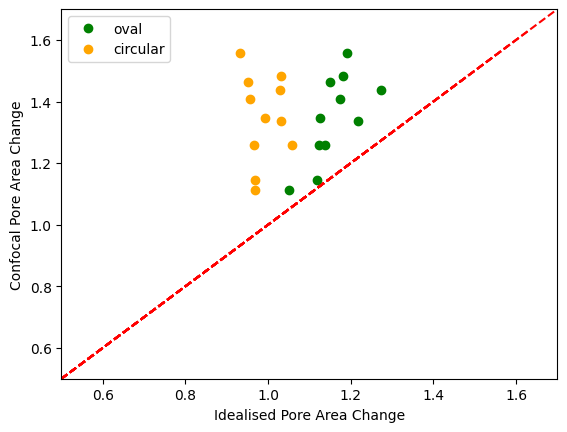

In [45]:
## For each mesh, plot the pressure vs pore area for all meshes on one plot

## There's a problem with 3_6 and 3_7: remove these for now


for mesh in chosen_mesh:
    idealised_oval = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "oval")]
    idealised_circular = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "circular")]
    mesh_data_confocal = df_full[df_full["Mesh ID"].str.contains(mesh)]
    if idealised_oval.empty or mesh_data_confocal.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    idealised_oval_start = idealised_oval[idealised_oval["Pressure (MPa)"] == 0.0]
    idealised_circular_start = idealised_circular[idealised_circular["Pressure (MPa)"] == 0.0]
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]
    idealised_oval_end = idealised_oval[idealised_oval["Pressure (MPa)"] == idealised_oval["Pressure (MPa)"].max()]
    idealised_circular_end = idealised_circular[idealised_circular["Pressure (MPa)"] == idealised_circular["Pressure (MPa)"].max()]
    mesh_data_confocal_end = mesh_data_confocal[mesh_data_confocal["Pressure"] == mesh_data_confocal["Pressure"].max()]
    idealised_oval_pore_area_change = (idealised_oval_end["Pore Area (um^2)"].values[0]/ idealised_oval_start["Pore Area (um^2)"].values[0])
    idealised_circular_pore_area_change = (idealised_circular_end["Pore Area (um^2)"].values[0] / idealised_circular_start["Pore Area (um^2)"].values[0])
    confocal_pore_area_change = (mesh_data_confocal_end["Pore Area"].values[0] / mesh_data_confocal_start["Pore Area"].values[0])

    plt.plot(idealised_oval_pore_area_change, confocal_pore_area_change, 'o', label="oval", color=colours['simplified_oval'])
    plt.plot(idealised_circular_pore_area_change, confocal_pore_area_change, 'o', label="circular", color=colours['simplified_circular'])
    ## Plot y=x in red
    plt.plot([0, max(idealised_oval_pore_area_change, idealised_circular_pore_area_change, confocal_pore_area_change)*1.1], 
             [0, max(idealised_oval_pore_area_change, idealised_circular_pore_area_change, confocal_pore_area_change)*1.1], 
             'r--', label='y=x')
    plt.xlabel("Idealised Pore Area Change")
    plt.ylabel("Confocal Pore Area Change")

# Example: Restrict legend to the first two elements
handles, labels = plt.gca().get_legend_handles_labels()  # Get all handles and labels
plt.legend(handles[:2], labels[:2])  # Use only the first two elements
plt.xlim(0.5, 1.7)
plt.ylim(0.5, 1.7)
plt.savefig("idealised_vs_confocal_pore_area_change.png", dpi=300)
plt.show()

Skipping mesh 1_2 due to missing data.


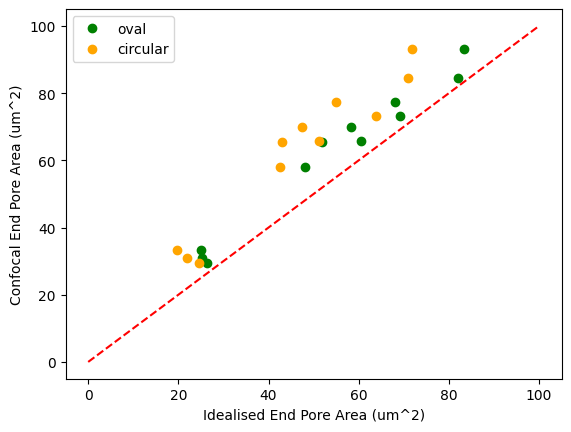

In [46]:
for mesh in chosen_mesh:
    idealised_oval = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "oval")]
    idealised_circular = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "circular")]
    mesh_data_confocal = df_full[df_full["Mesh ID"].str.contains(mesh)]
    if idealised_oval.empty or mesh_data_confocal.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    idealised_oval_start = idealised_oval[idealised_oval["Pressure (MPa)"] == 0.0]
    idealised_circular_start = idealised_circular[idealised_circular["Pressure (MPa)"] == 0.0]
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]
    idealised_oval_end = idealised_oval[idealised_oval["Pressure (MPa)"] == idealised_oval["Pressure (MPa)"].max()]
    idealised_circular_end = idealised_circular[idealised_circular["Pressure (MPa)"] == idealised_circular["Pressure (MPa)"].max()]
    mesh_data_confocal_end = mesh_data_confocal[mesh_data_confocal["Pressure"] == mesh_data_confocal["Pressure"].max()]

    plt.plot(idealised_oval_end["Pore Area (um^2)"], mesh_data_confocal_end["Pore Area"], 'o', label="oval", color=colours['simplified_oval'])
    plt.plot(idealised_circular_end["Pore Area (um^2)"], mesh_data_confocal_end["Pore Area"], 'o', label="circular", color=colours['simplified_circular'])
    ## Plot y=x in red
    

    plt.xlabel("Idealised End Pore Area (um^2)")
    plt.ylabel("Confocal End Pore Area (um^2)")
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='y=x line')
# Example: Restrict legend to the first two elements
handles, labels = plt.gca().get_legend_handles_labels()  # Get all handles and labels
plt.legend(handles[:2], labels[:2])  # Use only the first two elements

plt.savefig("idealised_vs_confocal_pore_area_end.png", dpi=300)
plt.show()

Skipping mesh 1_2 due to missing data.


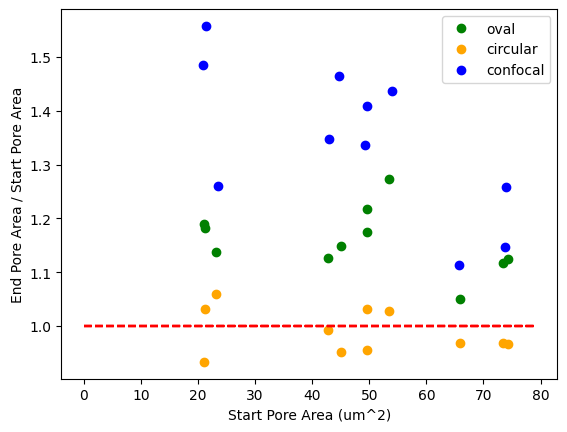

In [47]:
for mesh in chosen_mesh:
    idealised_oval = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "oval")]
    idealised_circular = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "circular")]
    mesh_data_confocal = df_full[df_full["Mesh ID"].str.contains(mesh)]
    if idealised_oval.empty or mesh_data_confocal.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    idealised_oval_start = idealised_oval[idealised_oval["Pressure (MPa)"] == 0.0]
    idealised_circular_start = idealised_circular[idealised_circular["Pressure (MPa)"] == 0.0]
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]
    idealised_oval_end = idealised_oval[idealised_oval["Pressure (MPa)"] == idealised_oval["Pressure (MPa)"].max()]
    idealised_circular_end = idealised_circular[idealised_circular["Pressure (MPa)"] == idealised_circular["Pressure (MPa)"].max()]
    mesh_data_confocal_end = mesh_data_confocal[mesh_data_confocal["Pressure"] == mesh_data_confocal["Pressure"].max()]
    idealised_oval_pore_area_change = (idealised_oval_end["Pore Area (um^2)"].values[0]/ idealised_oval_start["Pore Area (um^2)"].values[0])
    idealised_circular_pore_area_change = (idealised_circular_end["Pore Area (um^2)"].values[0] / idealised_circular_start["Pore Area (um^2)"].values[0])
    confocal_pore_area_change = (mesh_data_confocal_end["Pore Area"].values[0] / mesh_data_confocal_start["Pore Area"].values[0])

    plt.plot(idealised_oval_start["Pore Area (um^2)"].values[0], idealised_oval_pore_area_change, 'o', label="oval", color=colours['simplified_oval'])
    plt.plot(idealised_circular_start["Pore Area (um^2)"].values[0], idealised_circular_pore_area_change, 'o', label="circular", color=colours['simplified_circular'])
    plt.plot(mesh_data_confocal_start["Pore Area"].values[0], confocal_pore_area_change, 'o', label="confocal", color=colours['realistic'])
    ## Plot y=1 in red
    xs = np.arange(0,80)
    ys = np.ones(len(xs))
    plt.plot(xs, ys, 'r--', label='y=1')

plt.xlabel("Start Pore Area (um^2)")
plt.ylabel("End Pore Area / Start Pore Area")

# Example: Restrict legend to the first two elements
handles, labels = plt.gca().get_legend_handles_labels()  # Get all handles and labels
plt.legend(handles[:3], labels[:3])  # Use only the first three elements

plt.savefig("idealised_confocal_above_one.png", dpi=300)
plt.show()

In [48]:
## Let's visualise the cross sections on a mesh

mesh_id = "1_2"
import trimesh
meshfile = f"../Meshes/Onion_OBJ/Ac_DA_{mesh_id}.obj"
mesh = trimesh.load(meshfile, force='mesh')

from cross_section_helpers import visualize_mesh, analyze_stomata_mesh

section_points_right, section_points_left, section_traces_left, section_traces_right = analyze_stomata_mesh(meshfile)



tip = section_traces_left[0]
mid_index = len(section_traces_left) // 2
midsection = section_traces_left[mid_index]


In [49]:
## Make new traces, thinner lines and more opacity
import plotly.graph_objects as go

section_traces = []
for section in section_points_left:
    trace = go.Scatter3d(
        x=section[:, 0],  # X-coordinates
        y=section[:, 1],  # Y-coordinates
        z=section[:, 2],  # Z-coordinates
        mode='lines',     # Line mode
        line=dict(width=2, color='blue'),  # Thinner line
        name='Cross-section',
        opacity=0.5       # More opacity
    )
    section_traces.append(trace)
tip = section_points_left[0]
mid_index = len(section_points_left) // 2
midsection = section_points_left[mid_index]

midsection_trace = go.Scatter3d(
    x=midsection[:,0],  # X-coordinate
    y=midsection[:,1],  # Y-coordinate
    z=midsection[:,2],  # Z-coordinate
    mode='lines',     # Only markers
    line=dict(width=5, color='red'),  # Marker style
    name='Midsection',
    opacity=1         # Legend name
)
tip_trace = go.Scatter3d(
    x=tip[:,0],  # X-coordinate
    y=tip[:,1],  # Y-coordinate
    z=tip[:,2],  # Z-coordinate
    mode='lines',     # Only markers
    line=dict(width=5, color='green'),  # Thinner line
    name='Tip',
    opacity=1         # Legend name
)

output = visualize_mesh(mesh, [tip_trace, midsection_trace] + section_traces )
output.write_html("mesh_with_cross_sections.html")

In [50]:
## Plot volume vs pore area
plt.scatter(df_full['Volume norm'], df_full['Pore Area'], marker='o', color='blue')
plt.xlabel('Normalised Volume')
plt.ylabel('Pore Area')
plt.grid(True)
plt.show()

KeyError: 'Volume norm'

In [ ]:
## Get volume measurements for the idealised meshes


AttributeError: module 'idealised_mesh_functions' has no attribute 'get_idealised_volume_and_area'